In [ ]:
!pip install -q scikit-plot scipy==1.7.3 imbalanced-learn

In [ ]:
from numpy import interp
import numpy as np
import pandas as pd
import seaborn as sns
import scikitplot as skplt
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Embedding, LSTM, GlobalAveragePooling2D
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPool1D, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
plt.style.use('ggplot')

In [4]:
data = pd.read_csv('/kaggle/input/dynamic_api_call_sequence_per_malware_100_0_306.csv')

In [5]:
data.head()

,hash,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,...,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99,malware
0,071e8c3f8922e186e57548cd4c703a5d,112,274,158,215,274,158,215,298,76,...,71,297,135,171,215,35,208,56,71,1
1,33f8e6d08a6aae939f25a8e0d63dd523,82,208,187,208,172,117,172,117,172,...,81,240,117,71,297,135,171,215,35,1
2,b68abd064e975e1c6d5f25e748663076,16,110,240,117,240,117,240,117,240,...,65,112,123,65,112,123,65,113,112,1
3,72049be7bd30ea61297ea624ae198067,82,208,187,208,172,117,172,117,172,...,208,302,208,302,187,208,302,228,302,1
4,c9b3700a77facf29172f32df6bc77f48,82,240,117,240,117,240,117,240,117,...,209,260,40,209,260,141,260,141,260,1


In [6]:
missing_values = data.isnull().sum()
print("Number of missing values in each column:\n", missing_values)
if missing_values.sum() == 0:
    print("The dataset does not have any missing values.")
else:
    print("The dataset has missing values.")


Number of missing values in each column:
 hash       0
t_0        0
t_1        0
t_2        0
t_3        0
          ..
t_96       0
t_97       0
t_98       0
t_99       0
malware    0
Length: 102, dtype: int64
The dataset does not have any missing values.


In [7]:
used_data = data.drop(['hash', 'malware'], axis=1)

used_data.head()

,t_0,t_1,t_2,t_3,t_4,t_5,t_6,t_7,t_8,t_9,...,t_90,t_91,t_92,t_93,t_94,t_95,t_96,t_97,t_98,t_99
0,112,274,158,215,274,158,215,298,76,208,...,117,71,297,135,171,215,35,208,56,71
1,82,208,187,208,172,117,172,117,172,117,...,60,81,240,117,71,297,135,171,215,35
2,16,110,240,117,240,117,240,117,240,117,...,123,65,112,123,65,112,123,65,113,112
3,82,208,187,208,172,117,172,117,172,117,...,215,208,302,208,302,187,208,302,228,302
4,82,240,117,240,117,240,117,240,117,172,...,40,209,260,40,209,260,141,260,141,260


## Classes distribution

In [8]:
print(data['malware'].unique())
print(data['malware'].value_counts())

[1 0]
malware
1    42797
0     1079
Name: count, dtype: int64


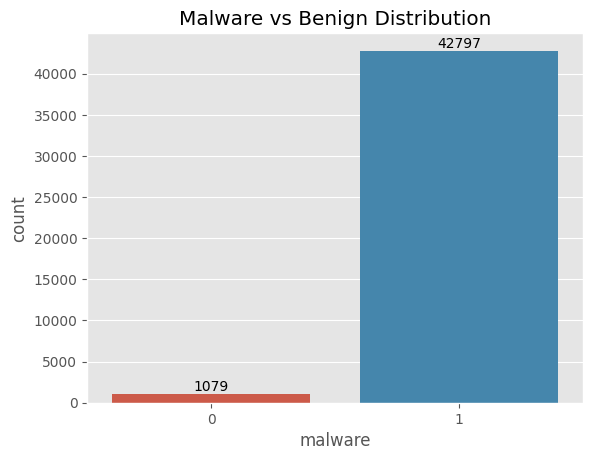

In [9]:
ax = sns.countplot(data=data, x='malware')
for bar in ax.patches:
    ax.annotate(f'{int(bar.get_height())}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.title("Malware vs Benign Distribution")
plt.show()


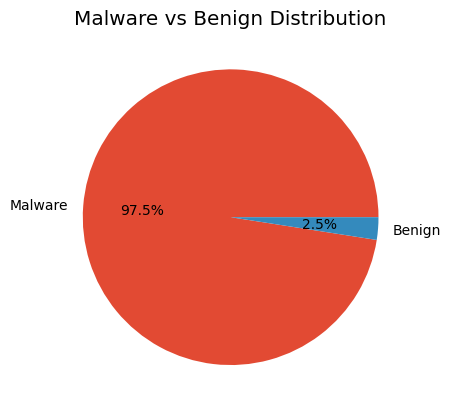

In [10]:
data['malware'].value_counts().plot(kind='pie', autopct='%1.1f%%', labels=['Malware', 'Benign'])
plt.title("Malware vs Benign Distribution")
plt.ylabel("")
plt.show()

# Distribution Inbalanced -> Balance with SMOTE

In [11]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

In [12]:
def preprocess_data(data):
    """
    Preprocess the data by removing unnecessary columns and splitting features and labels.
    """
    data_clean = data.drop(['hash'], axis=1)
    X = data_clean.drop('malware', axis=1)
    y = data_clean['malware']
    return X, y

In [13]:
def split_data(X, y, test_size=0.2, random_state=42):
    """
    Split data into training and testing sets.
    """
    return train_test_split(X, y, test_size=test_size, random_state=random_state)

In [14]:
def scale_data(X_train, X_test):
    """
    Scale the training and testing data.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    return X_train_scaled, X_test_scaled


In [15]:
def apply_smote(X_train, y_train, random_state=42):
    """
    Apply SMOTE to handle class imbalance in training data.
    """
    smote = SMOTE(sampling_strategy='auto', random_state=random_state)
    return smote.fit_resample(X_train, y_train)


In [17]:
X, y = preprocess_data(data)
print("Class distribution before SMOTE:")
print(y.value_counts())

Class distribution before SMOTE:
malware
1    42797
0     1079
Name: count, dtype: int64


In [19]:
# Split data
X_train, X_test, y_train, y_test = split_data(X, y)
print("Training data class distribution:")
print(y_train.value_counts())

Training data class distribution:
malware
1    34247
0      853
Name: count, dtype: int64


In [20]:
# Scale data
X_train_scaled, X_test_scaled = scale_data(X_train, X_test)

# Apply SMOTE
X_train_smote, y_train_smote = apply_smote(X_train_scaled, y_train)
print("Class distribution after SMOTE:")
print(y_train_smote.value_counts())

Class distribution after SMOTE:
malware
1    34247
0    34247
Name: count, dtype: int64


### Splitting the Data

In [21]:
X_train, X_test, y_train, y_test = train_test_split(used_data, data['malware'], test_size=0.25,
                                                    shuffle=True, random_state=42)

In [22]:
X_train.shape

(32907, 100)

### Building the model

In [58]:
unique_api_calls = 307

In [23]:
print(X_train.shape)
print(y_train.shape)

(32907, 100)
(32907,)


In [24]:
print(f"After SMOTE train data size: X_train_smote.shape: {X_train_smote.shape}")
print(f"After SMOTE tag data size: y_train_smote.shape: {y_train_smote.shape}")

print("After SMOTE Class Distribution:")
print(y_train_smote.value_counts())

After SMOTE train data size: X_train_smote.shape: (68494, 100)
After SMOTE tag data size: y_train_smote.shape: (68494,)
After SMOTE Class Distribution:
malware
1    34247
0    34247
Name: count, dtype: int64


In [28]:
print(X_train.isnull().sum())
print(y_train.isnull().sum())

t_0     0
t_1     0
t_2     0
t_3     0
t_4     0
       ..
t_95    0
t_96    0
t_97    0
t_98    0
t_99    0
Length: 100, dtype: int64
0


In [29]:
print(type(X_train))
print(type(y_train))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


In [30]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')


In [31]:
X_train.fillna(0, inplace=True)
y_train.fillna(0, inplace=True)


In [32]:
X_train = np.array(X_train)
y_train = np.array(y_train)

### Last Controls

In [68]:
print(type(X_test))
print(X_test.shape)

<class 'pandas.core.frame.DataFrame'>
(10969, 100)


In [33]:
X_test = np.array(X_test)

In [34]:
print(type(X_test))
print(X_test.dtype)
print(X_test[:5]) 

<class 'numpy.ndarray'>
int64
[[112 274 158 215 274 158 215 298  76 208  76 172 117 172 117 172  76 117
   35  60  81  60  81  60  81  60  81  60  81  60  81  60  81  60  81  60
   81  60  81  60  81  60  81  60  81  60  81 117  60  81  60  81 208  35
  215  35 208 240 117 172  60  81  60  81 225  35  60  81  35 225 172  60
   81  60  81  60  81 172 117 172 117 172 117 208 240 117 240 117 187 172
  117 240 117 159 208 187 228 208 240 208]
 [286 110 172 240 117 240 117 240 117 106 171 260 141  65 260 141  65 260
  141  65 260 141  65 260 141  65 260 215 240 117  71 297 135 171 215 112
  117  56 240 117 240 117 260 141  65 260 117 260 141  65 117 260 141  65
  117   9 117 260  65 141  65 260  65 141  65 117 215  89 260  65 141  65
  172 117 172 117 172 117 260 240 117 240 117 202 260 262 141  65 202  65
  112 117 260 123  65 274 158 215 274 158]
 [112 274 158 215 274 158 215 298  76 208  76 172 117 172 117 172  76 117
   35  60  81  60  81  60  81  60  81  60  81  60  81  60  81  60  81 

In [55]:
# Convert to NumPy array and ensure float32 data type
X_test = np.array(X_test, dtype=np.float32)

# Evaluating the Models

In [56]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Embedding, Conv1D, MaxPooling1D, LSTM, Dense, Flatten, BatchNormalization, Dropout, Input, LayerNormalization, GRU, Bidirectional, Attention, Lambda, Add
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, recall_score, precision_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow.keras.backend as K
from sklearn.metrics import roc_curve, roc_auc_score
from tensorflow.keras.layers import Dense, Dropout, Add, Input
from tensorflow.keras.models import Model
from sklearn.utils.class_weight import compute_class_weight

In [57]:
# Helper function to evaluate and store metrics
def evaluate_and_store_metrics(model_name, y_test, y_pred, y_pred_prob):
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    report = classification_report(y_test, y_pred, digits=4, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_test, y_pred, digits=4))
    print(f"\nConfusion Matrix for {model_name}:")
    print(cm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f"Confusion Matrix for {model_name}")
    plt.show()

    # Plot ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal reference line
    plt.xlabel('False Positive Rate (FPR)')
    plt.ylabel('True Positive Rate (TPR)')
    plt.title(f'ROC Curve for {model_name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.show()
    
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "False Positives (FP)": fp,
        "False Negatives (FN)": fn,
        "ROC-AUC": roc_auc
    }

In [66]:
# Function to plot loss and accuracy
def plot_loss_accuracy(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} - Training and Validation Loss')
    plt.legend()

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} - Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()


In [67]:
# Train and evaluate Simple ANN
def train_simple_ann(X_train, y_train, X_test, y_test, epoch):
    model = Sequential(name="Simple_ANN_Model")
    model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))  # Increased units
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))  # Added an additional layer with more units
    model.add(Dropout(0.3))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(16, activation='relu'))  # Added another dense layer
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epoch, batch_size=128, verbose=0)

    y_pred_prob = model.predict(X_test).flatten()  # Probabilities
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    
    plot_loss_accuracy(history, "Simple_ANN_Model")
    
    return evaluate_and_store_metrics("Simple_ANN_Model", y_test, y_pred, y_pred_prob)


In [68]:
# Train and evaluate MLP Model
def train_mlp(X_train, y_train, X_test, y_test, epoch):
    model = Sequential(name="MLP_Model")
    model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(0.3))
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epoch, batch_size=128, verbose=0)

    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    
    plot_loss_accuracy(history, "MLP_Model")
    
    return evaluate_and_store_metrics("MLP_Model", y_test, y_pred, y_pred_prob)

In [69]:
# Train and evaluate DropConnect ANN (Enhanced)
def train_dropconnect_ann(X_train, y_train, X_test, y_test, epoch):
    model = Sequential(name="DropConnect_ANN_Model")
    
    # Input Layer
    model.add(Dense(128, activation='relu', input_dim=X_train.shape[1]))
    model.add(Dropout(0.3))  # Dropout layer to emulate DropConnect

    # Hidden Layer 1
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.3))  # Dropout layer for regularization

    # Hidden Layer 2
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.2))  # Adding another Dropout layer

    # Hidden Layer 3
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))  # Regularization to prevent overfitting

    # Output Layer
    model.add(Dense(1, activation='sigmoid'))  # Binary classification

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(
        X_train, 
        y_train, 
        validation_split=0.2, 
        epochs=epoch, 
        batch_size=128, 
        verbose=0
    )

    # Generate predictions
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (model.predict(X_test) > 0.5).astype("int32")

    # Plot training history
    plot_loss_accuracy(history, "Enhanced_DropConnect_ANN_Model")

    # Evaluate and return metrics
    return evaluate_and_store_metrics("Enhanced_DropConnect_ANN_Model", y_test, y_pred, y_pred_prob)

In [71]:
# Residual ANN
def train_residual_ann(X_train, y_train, X_test, y_test, epoch):
    inputs = Input(shape=(X_train.shape[1],))
    x = Dense(64, activation='relu')(inputs)
    x = Dropout(0.3)(x)
    
    # Residual Connection
    residual = Dense(64, activation='relu')(x)
    x = Add()([x, residual])  # Ensure dimensions match for residual connection
    
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs, name="Residual_ANN_Model")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    # Compute class weights
    class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
    class_weights = dict(enumerate(class_weights))
    
    # Train model
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epoch, batch_size=128, verbose=0, class_weight=class_weights)
    
    # Evaluate model
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    
    plot_loss_accuracy(history, "Residual_ANN_Model")
    
    return evaluate_and_store_metrics("Residual_ANN_Model", y_test, y_pred, y_pred_prob)

In [72]:
# Train and evaluate DenseNet ANN
def train_densenet_ann(X_train, y_train, X_test, y_test, epoch):
    inputs = Input(shape=(X_train.shape[1],))
    x = Dense(64, activation='relu')(inputs)
    dense1 = Dense(32, activation='relu')(x)
    x = tf.keras.layers.Concatenate()([x, dense1])  # Dense connection
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs=inputs, outputs=outputs, name="DenseNet_ANN_Model")
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epoch, batch_size=128, verbose=0)
    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    
    plot_loss_accuracy(history, "DenseNet_ANN_Model")
    
    return evaluate_and_store_metrics("DenseNet_ANN_Model", y_test, y_pred, y_pred_prob)

In [73]:
# Train and evaluate Radial Basis Function Network (RBF)
def train_rbf_network(X_train, y_train, X_test, y_test, epoch):
    from sklearn.kernel_approximation import RBFSampler
    rbf_sampler = RBFSampler(gamma=1, n_components=64, random_state=0)
    X_train_rbf = rbf_sampler.fit_transform(X_train)
    X_test_rbf = rbf_sampler.transform(X_test)
    model = Sequential(name="RBF_Network_Model")
    model.add(Dense(64, activation='relu', input_dim=X_train_rbf.shape[1]))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    history = model.fit(X_train_rbf, y_train, validation_split=0.2, epochs=epoch, batch_size=128, verbose=0)

    # PREDICT
    y_pred_prob = model.predict(X_test_rbf).flatten()  
    y_pred = (y_pred_prob > 0.5).astype("int32")
    
    plot_loss_accuracy(history, "RBF_Network_Model")
    
    return evaluate_and_store_metrics("RBF_Network_Model", y_test, y_pred, y_pred_prob)

In [74]:
# Train and evaluate CNN-LSTM Model
def train_cnn_lstm(X_train, y_train, X_test, y_test, unique_api_calls, epoch):
    model = Sequential(name="Cnn-Lstm_model")
    model.add(Embedding(input_dim=unique_api_calls, output_dim=8, input_length=X_train.shape[1], name='layer_embedding'))
    model.add(BatchNormalization())
    model.add(Conv1D(filters=32, kernel_size=9, padding='same', activation='relu'))
    model.add(MaxPool1D(pool_size=2))
    model.add(LSTM(units=512, return_sequences=False, dropout=0.2))
    model.add(Dense(units=1, activation='sigmoid'))
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=epoch, batch_size=128, verbose=0)

    y_pred_prob = model.predict(X_test).flatten()
    y_pred = (model.predict(X_test) > 0.5).astype("int32")
    
    plot_loss_accuracy(history, "Cnn-Lstm_model")
    
    return evaluate_and_store_metrics("Cnn-Lstm_model", y_test, y_pred, y_pred_prob)

# Train Models with Epoch 50

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


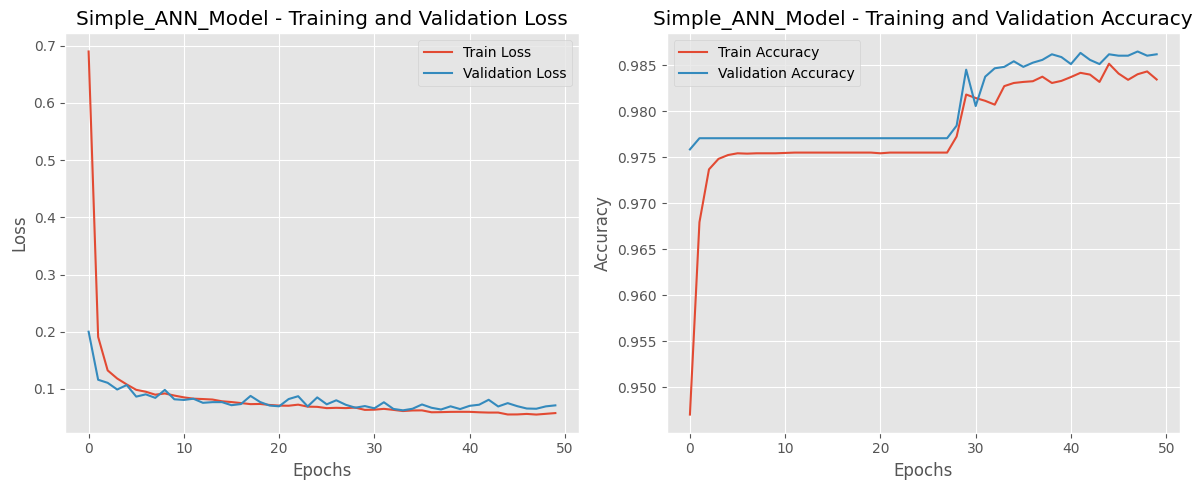


Classification Report for Simple_ANN_Model:
              precision    recall  f1-score   support

           0     0.8873    0.4452    0.5929       283
           1     0.9855    0.9985    0.9920     10686

    accuracy                         0.9842     10969
   macro avg     0.9364    0.7219    0.7924     10969
weighted avg     0.9830    0.9842    0.9817     10969


Confusion Matrix for Simple_ANN_Model:
[[  126   157]
 [   16 10670]]


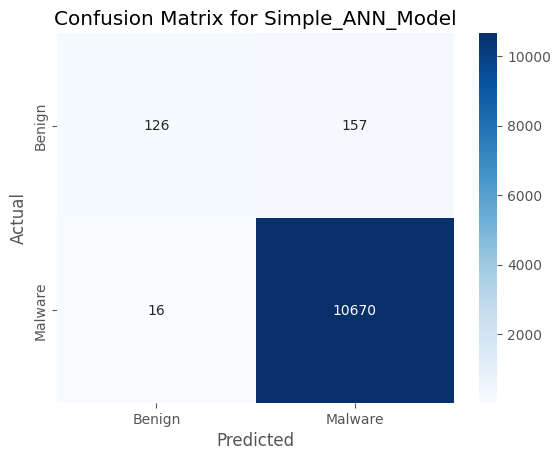

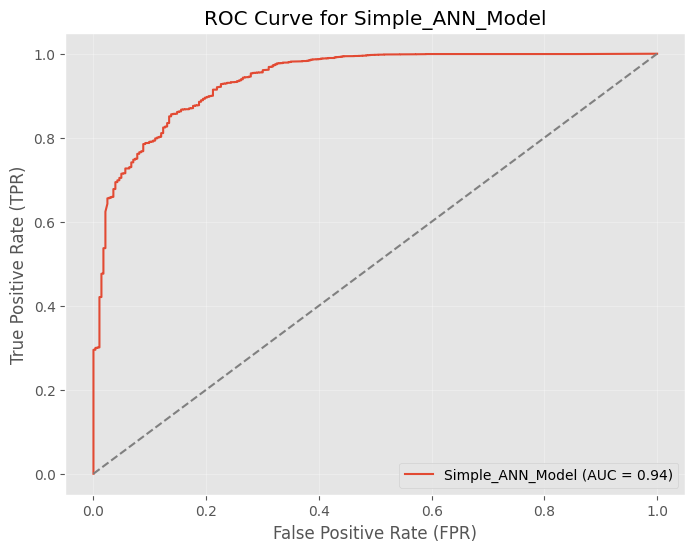

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


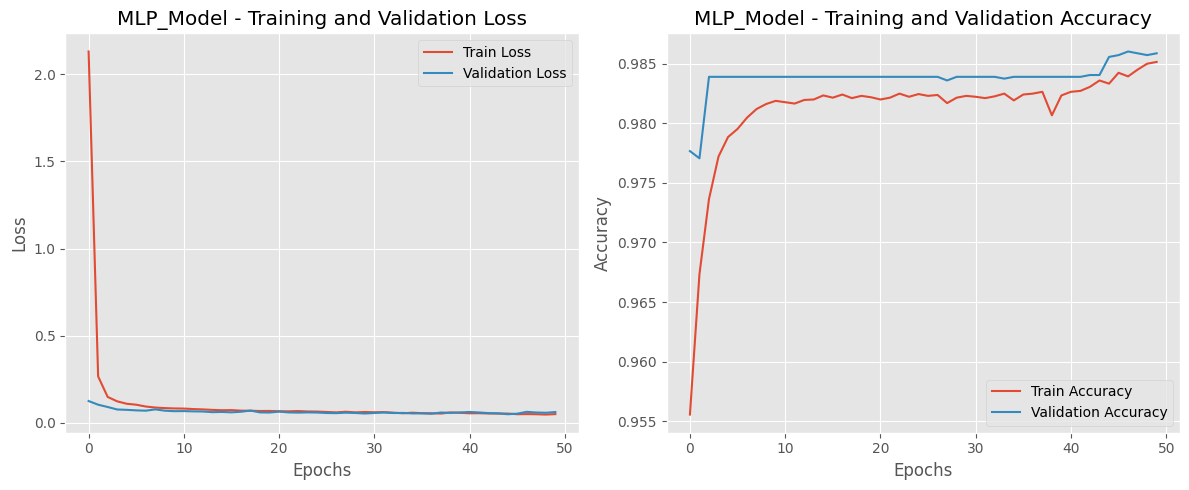


Classification Report for MLP_Model:
              precision    recall  f1-score   support

           0     0.9350    0.4064    0.5665       283
           1     0.9845    0.9993    0.9918     10686

    accuracy                         0.9840     10969
   macro avg     0.9597    0.7028    0.7792     10969
weighted avg     0.9832    0.9840    0.9809     10969


Confusion Matrix for MLP_Model:
[[  115   168]
 [    8 10678]]


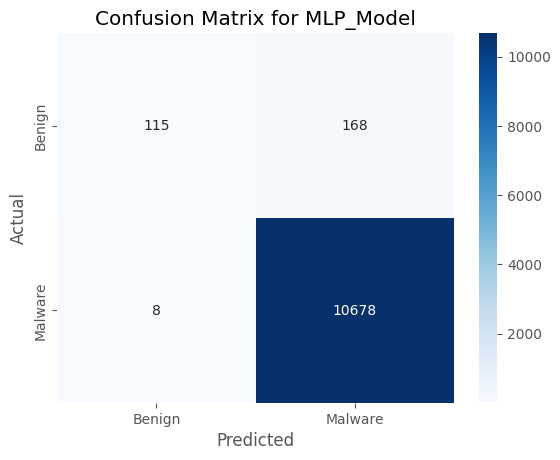

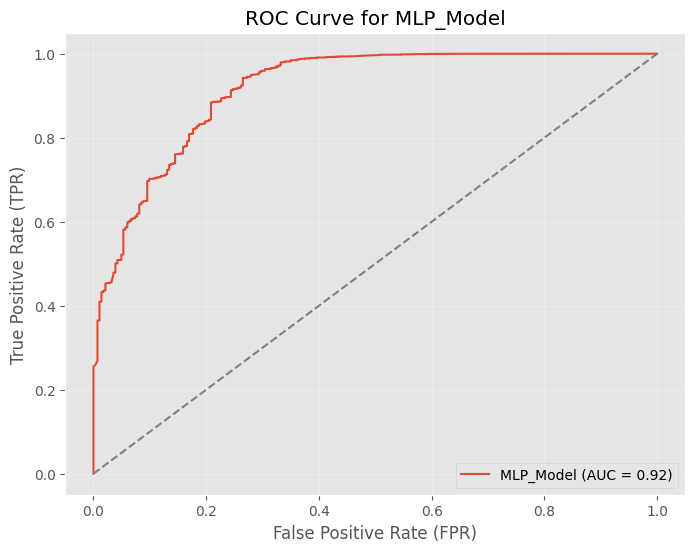

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


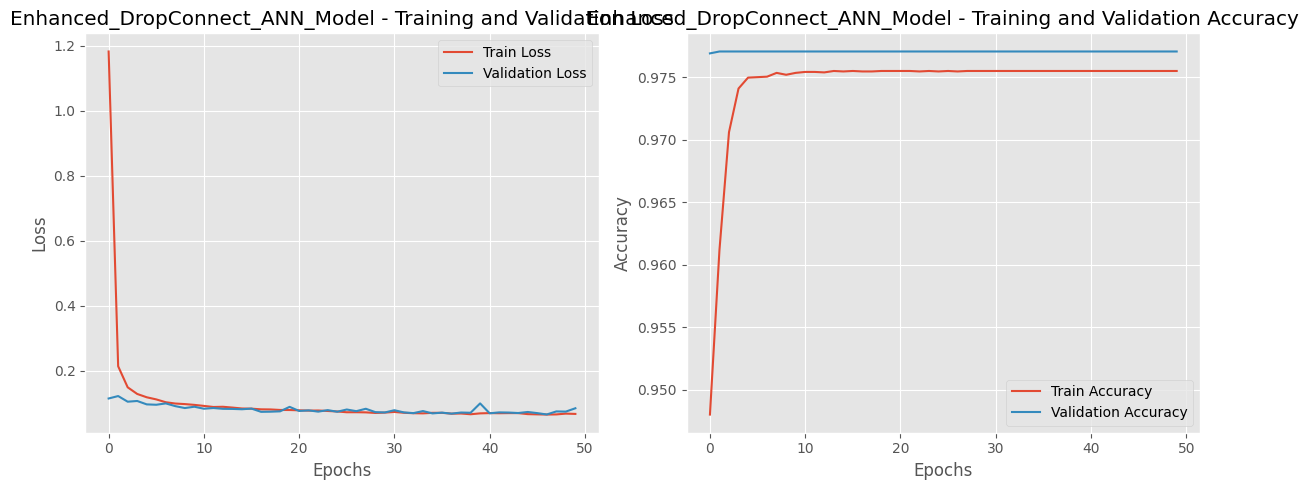

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classif


Classification Report for Enhanced_DropConnect_ANN_Model:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000       283
           1     0.9742    1.0000    0.9869     10686

    accuracy                         0.9742     10969
   macro avg     0.4871    0.5000    0.4935     10969
weighted avg     0.9491    0.9742    0.9615     10969


Confusion Matrix for Enhanced_DropConnect_ANN_Model:
[[    0   283]
 [    0 10686]]


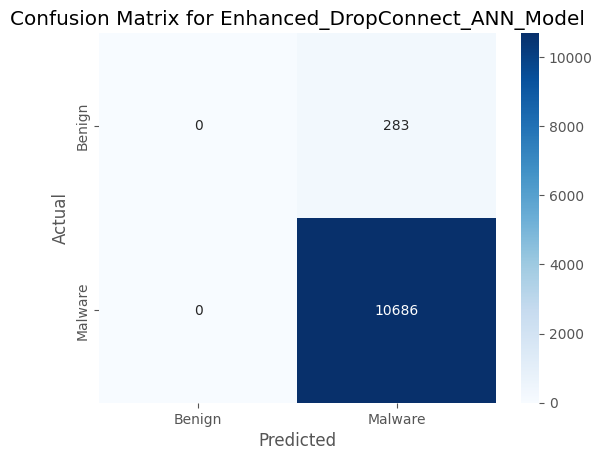

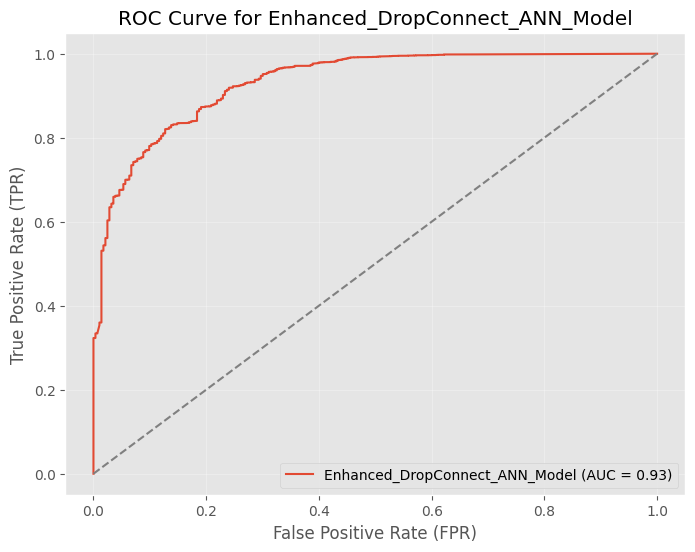

343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


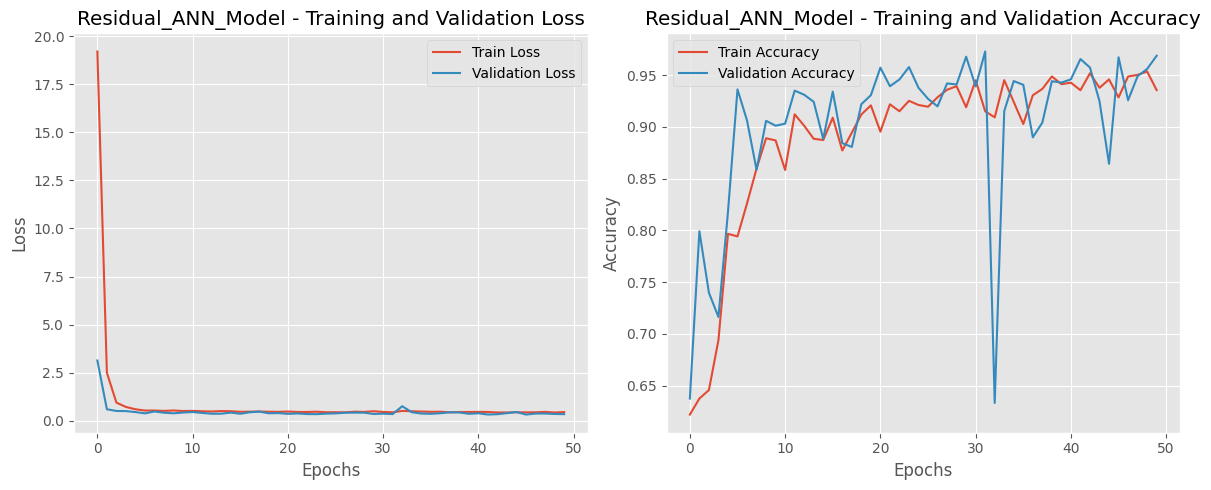


Classification Report for Residual_ANN_Model:
              precision    recall  f1-score   support

           0     0.4028    0.6148    0.4867       283
           1     0.9897    0.9759    0.9827     10686

    accuracy                         0.9665     10969
   macro avg     0.6962    0.7953    0.7347     10969
weighted avg     0.9745    0.9665    0.9699     10969


Confusion Matrix for Residual_ANN_Model:
[[  174   109]
 [  258 10428]]


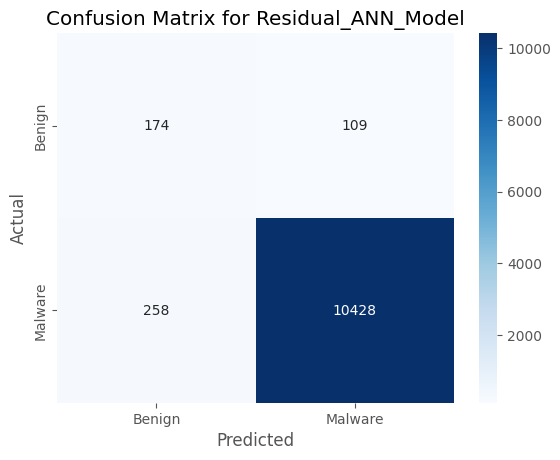

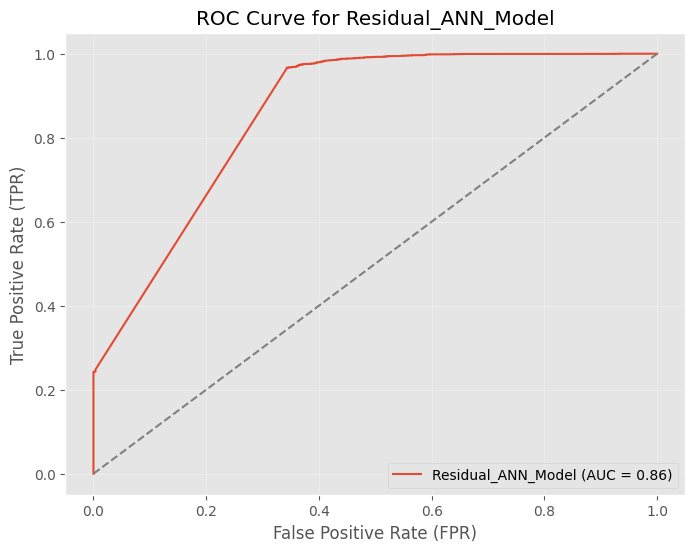

343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


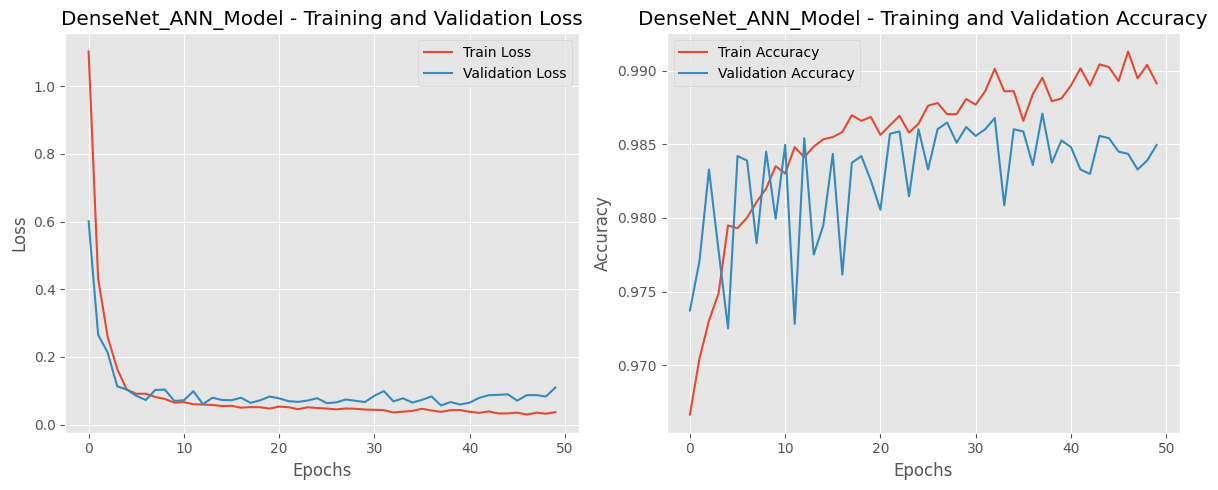


Classification Report for DenseNet_ANN_Model:
              precision    recall  f1-score   support

           0     0.8710    0.3816    0.5307       283
           1     0.9839    0.9985    0.9911     10686

    accuracy                         0.9826     10969
   macro avg     0.9274    0.6901    0.7609     10969
weighted avg     0.9810    0.9826    0.9793     10969


Confusion Matrix for DenseNet_ANN_Model:
[[  108   175]
 [   16 10670]]


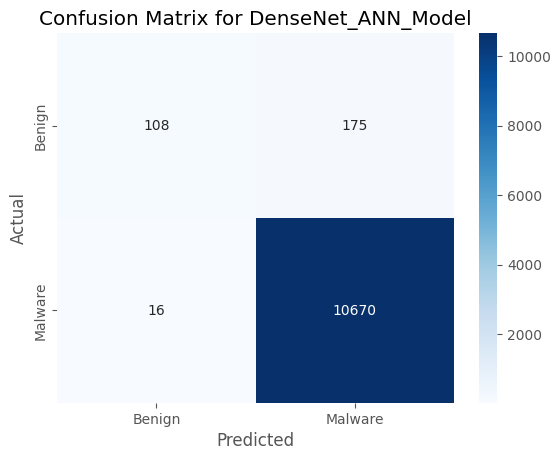

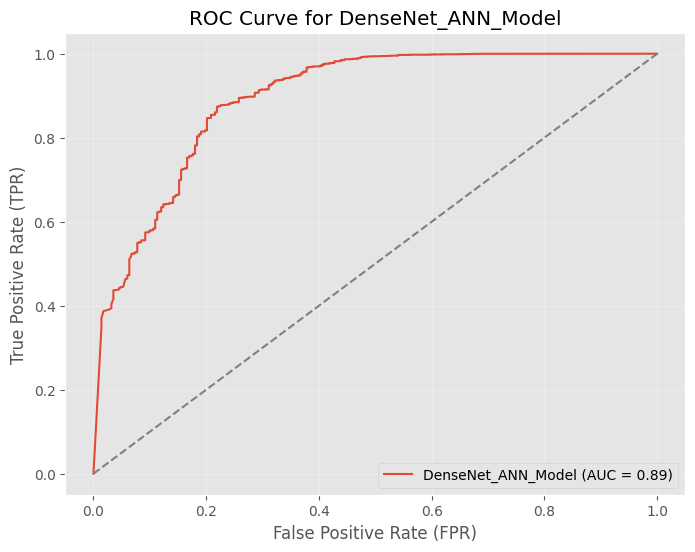

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


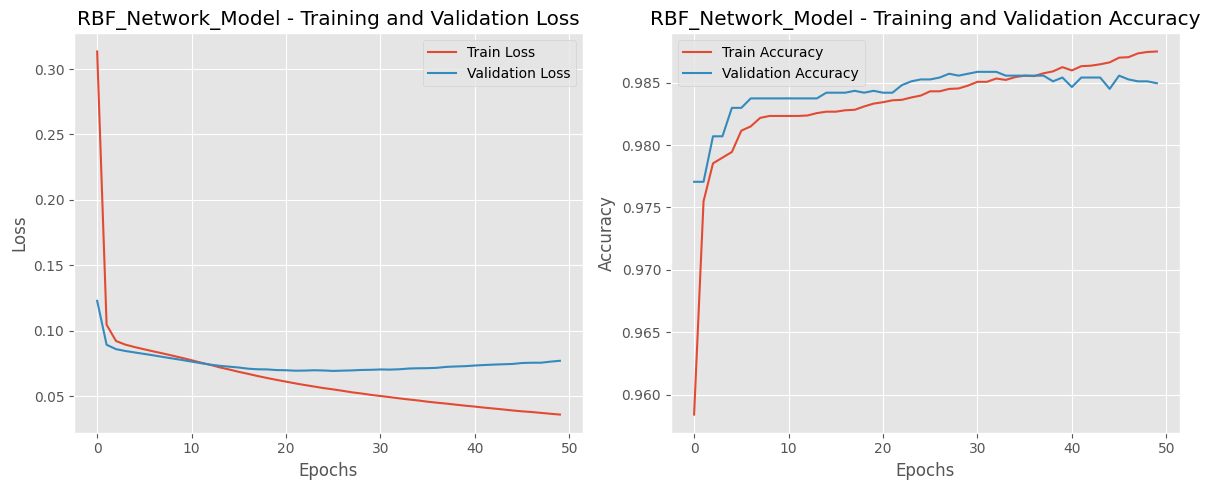


Classification Report for RBF_Network_Model:
              precision    recall  f1-score   support

           0     0.9153    0.3816    0.5387       283
           1     0.9839    0.9991    0.9914     10686

    accuracy                         0.9831     10969
   macro avg     0.9496    0.6903    0.7650     10969
weighted avg     0.9821    0.9831    0.9797     10969


Confusion Matrix for RBF_Network_Model:
[[  108   175]
 [   10 10676]]


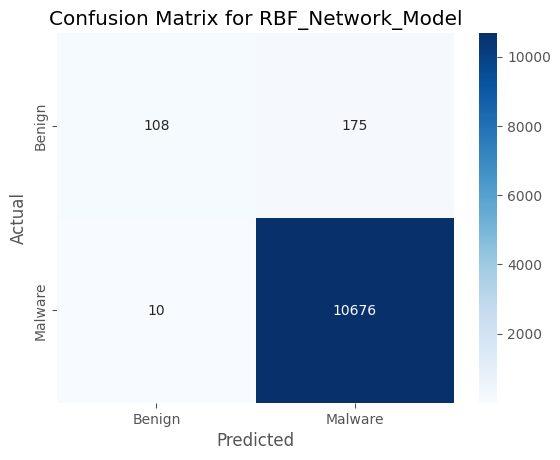

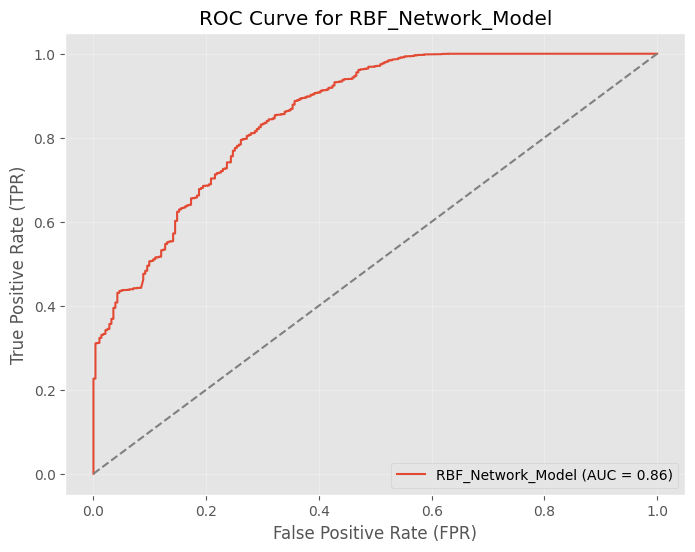

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


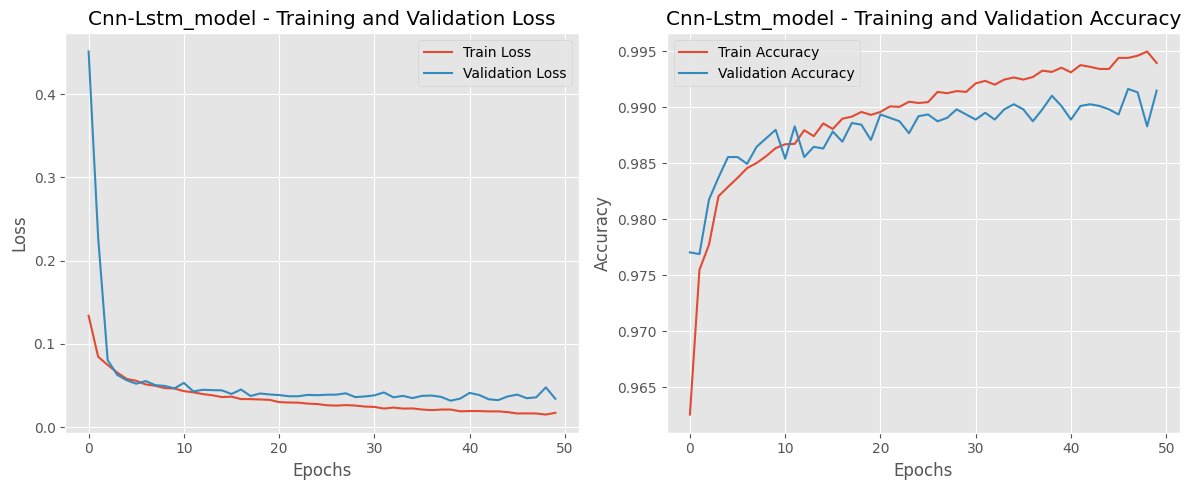


Classification Report for Cnn-Lstm_model:
              precision    recall  f1-score   support

           0     0.8511    0.7067    0.7722       283
           1     0.9923    0.9967    0.9945     10686

    accuracy                         0.9892     10969
   macro avg     0.9217    0.8517    0.8833     10969
weighted avg     0.9886    0.9892    0.9888     10969


Confusion Matrix for Cnn-Lstm_model:
[[  200    83]
 [   35 10651]]


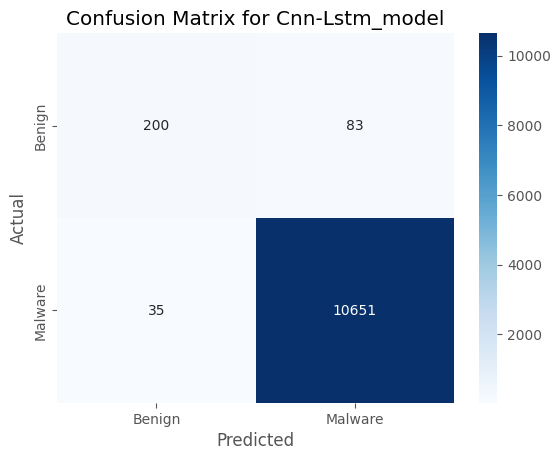

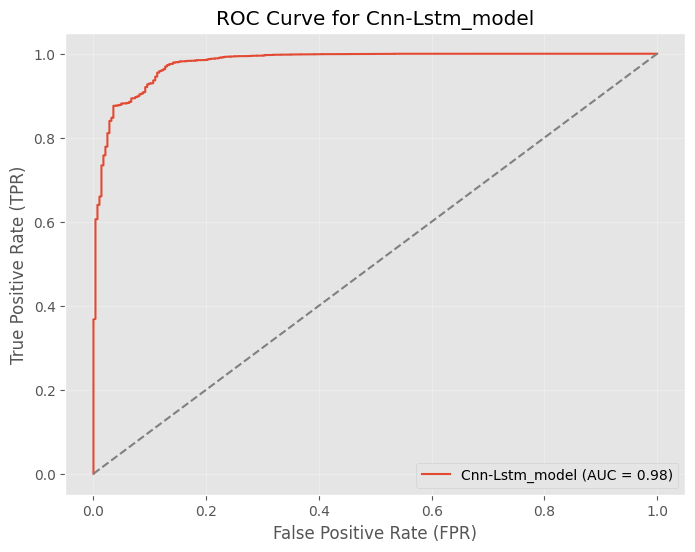

                            Model  Accuracy  F1-Score    Recall  Precision  \
6                  Cnn-Lstm_model  0.989242  0.994491  0.996725   0.992268   
0                Simple_ANN_Model  0.984228  0.991958  0.998503   0.985499   
1                       MLP_Model  0.983955  0.991826  0.999251   0.984510   
5               RBF_Network_Model  0.983134  0.991410  0.999064   0.983872   
4              DenseNet_ANN_Model  0.982587  0.991129  0.998503   0.983864   
2  Enhanced_DropConnect_ANN_Model  0.974200  0.986931  1.000000   0.974200   
3              Residual_ANN_Model  0.966542  0.982707  0.975856   0.989655   

   False Positives (FP)  False Negatives (FN)   ROC-AUC  
6                    83                    35  0.978785  
0                   157                    16  0.940061  
1                   168                     8  0.916966  
5                   175                    10  0.856193  
4                   175                    16  0.893621  
2                   283    

In [75]:
unique_api_calls = 307
epoch = 50

# List of models to train
results = []
results.append(train_simple_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_mlp(X_train, y_train, X_test, y_test, epoch))
results.append(train_dropconnect_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_residual_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_densenet_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_rbf_network(X_train, y_train, X_test, y_test, epoch))
results.append(train_cnn_lstm(X_train, y_train, X_test, y_test, unique_api_calls, epoch)) 

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["Accuracy", "ROC-AUC", "False Positives (FP)", "False Negatives (FN)"], ascending=[False, True, True,True])
print(df_results)


# Train Models with Epoch 150

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


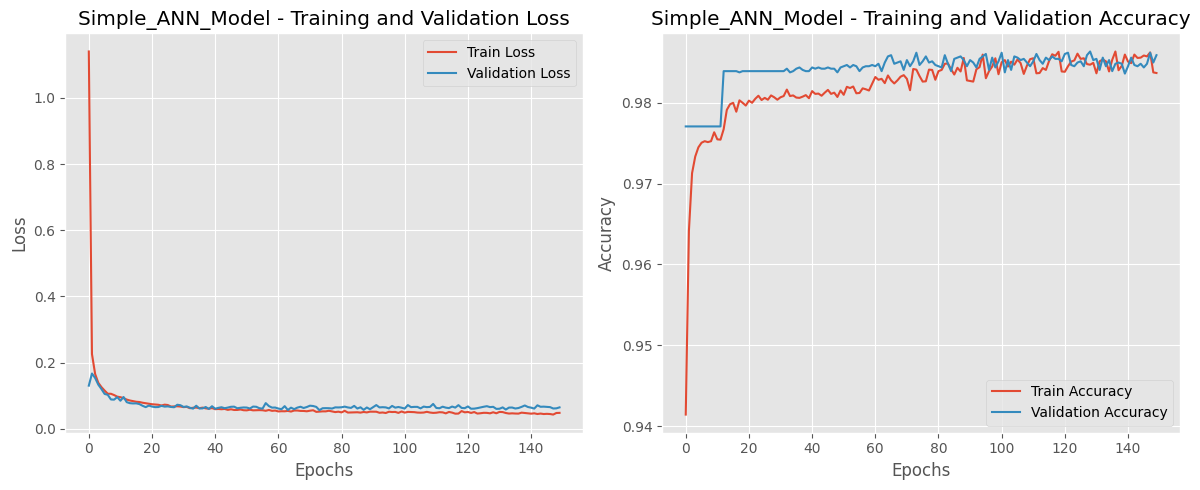


Classification Report for Simple_ANN_Model:
              precision    recall  f1-score   support

           0     0.7842    0.5265    0.6300       283
           1     0.9876    0.9962    0.9918     10686

    accuracy                         0.9840     10969
   macro avg     0.8859    0.7613    0.8109     10969
weighted avg     0.9823    0.9840    0.9825     10969


Confusion Matrix for Simple_ANN_Model:
[[  149   134]
 [   41 10645]]


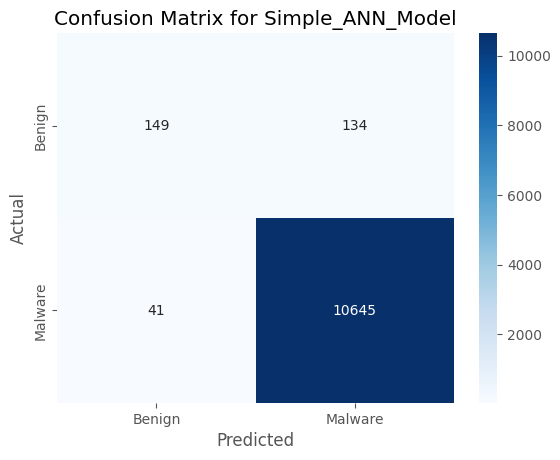

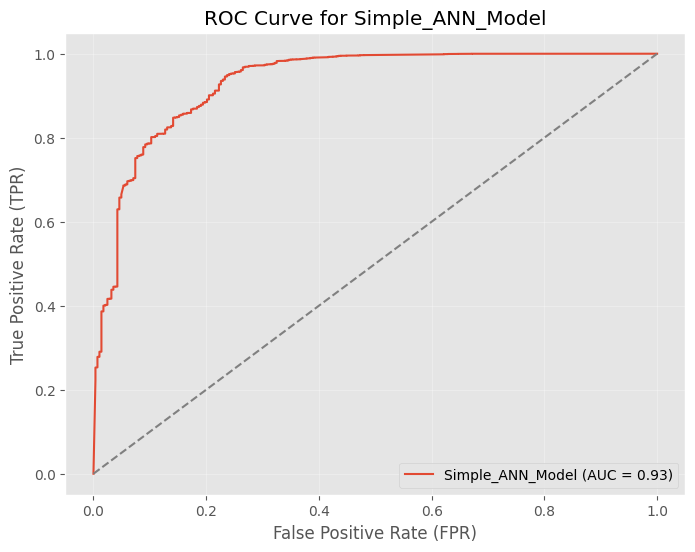

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


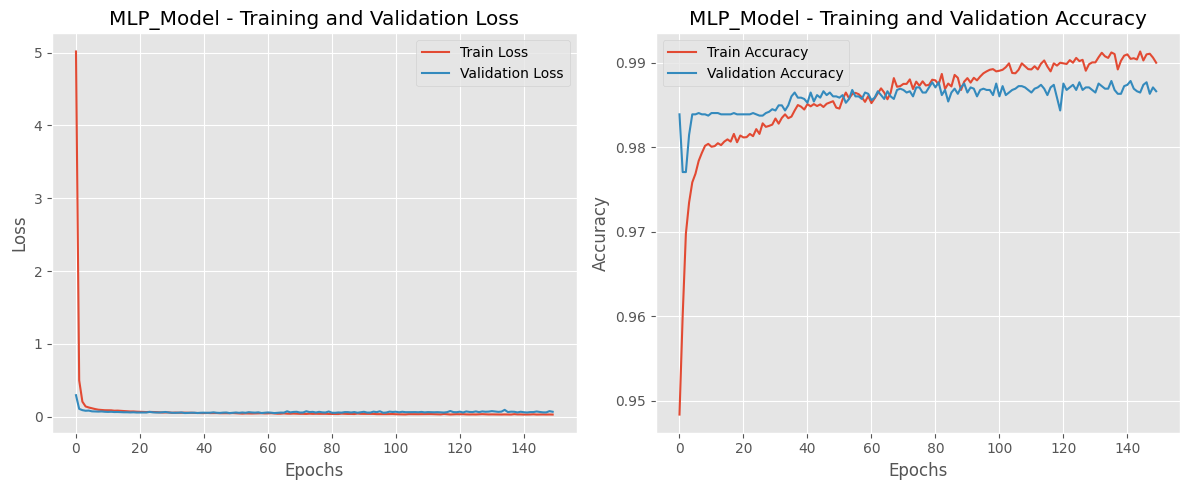


Classification Report for MLP_Model:
              precision    recall  f1-score   support

           0     0.7617    0.5194    0.6176       283
           1     0.9874    0.9957    0.9915     10686

    accuracy                         0.9834     10969
   macro avg     0.8745    0.7576    0.8046     10969
weighted avg     0.9816    0.9834    0.9819     10969


Confusion Matrix for MLP_Model:
[[  147   136]
 [   46 10640]]


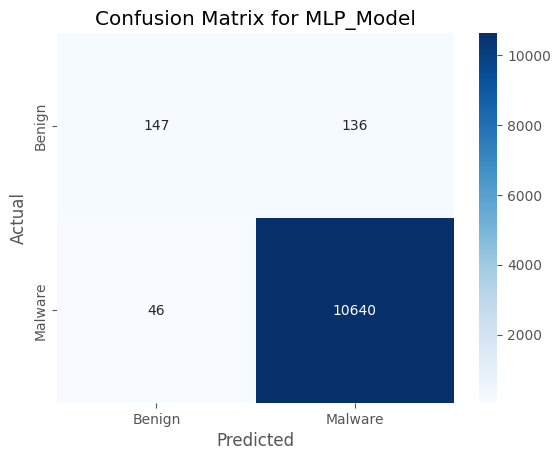

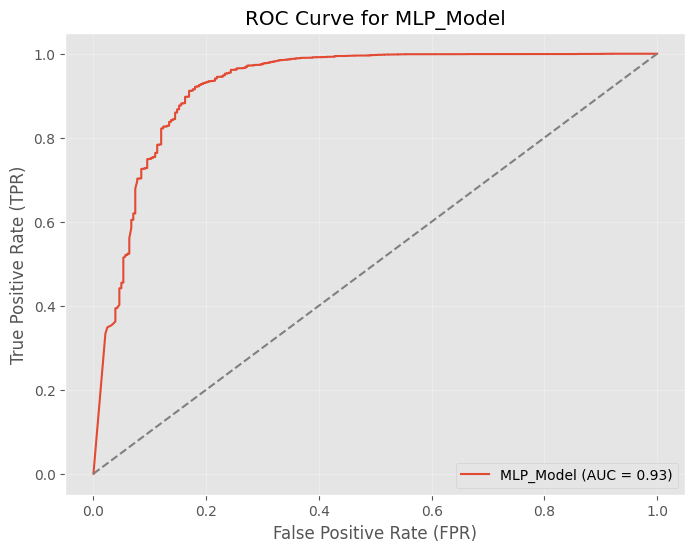

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


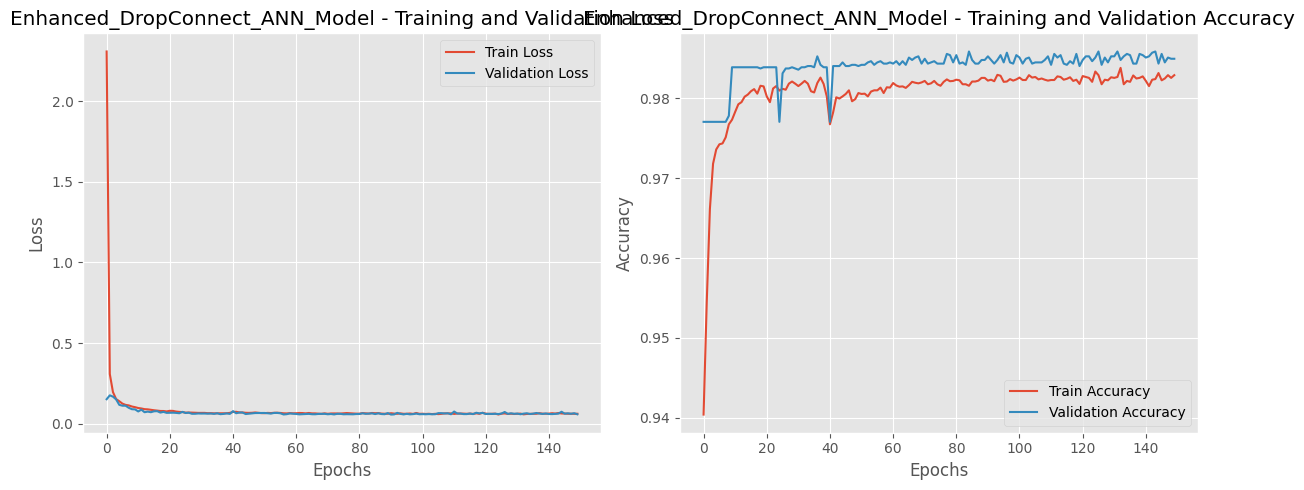


Classification Report for Enhanced_DropConnect_ANN_Model:
              precision    recall  f1-score   support

           0     0.9076    0.3816    0.5373       283
           1     0.9839    0.9990    0.9914     10686

    accuracy                         0.9830     10969
   macro avg     0.9457    0.6903    0.7643     10969
weighted avg     0.9819    0.9830    0.9796     10969


Confusion Matrix for Enhanced_DropConnect_ANN_Model:
[[  108   175]
 [   11 10675]]


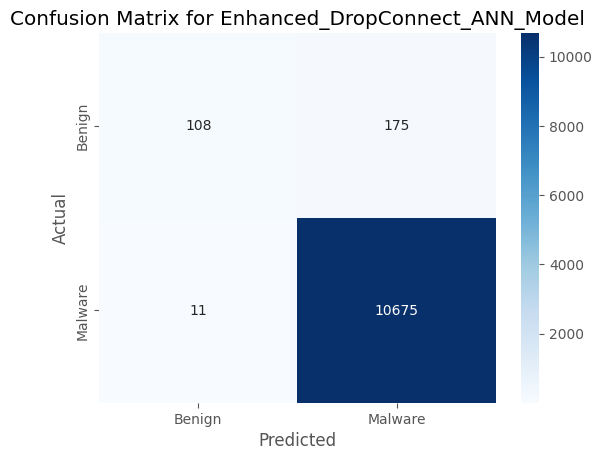

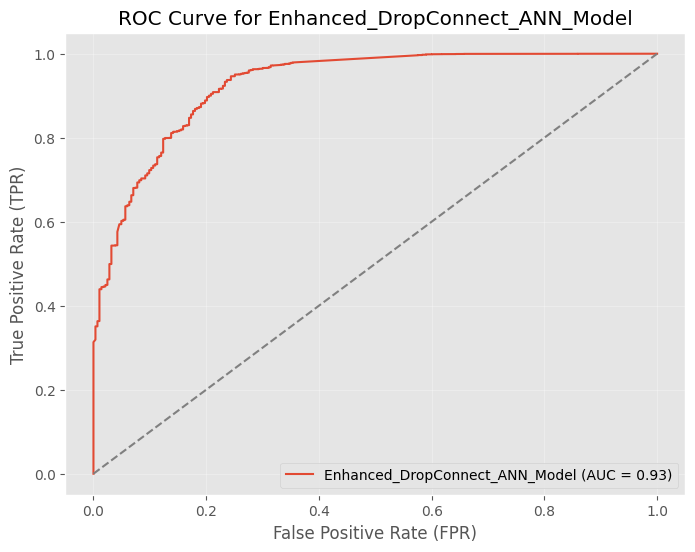

343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


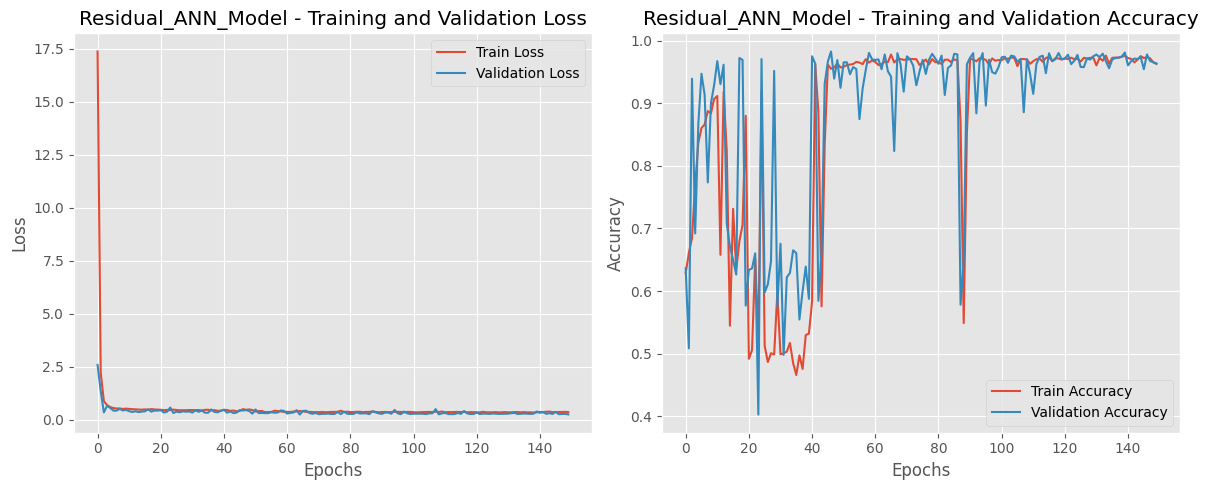


Classification Report for Residual_ANN_Model:
              precision    recall  f1-score   support

           0     0.3702    0.6148    0.4622       283
           1     0.9896    0.9723    0.9809     10686

    accuracy                         0.9631     10969
   macro avg     0.6799    0.7936    0.7215     10969
weighted avg     0.9736    0.9631    0.9675     10969


Confusion Matrix for Residual_ANN_Model:
[[  174   109]
 [  296 10390]]


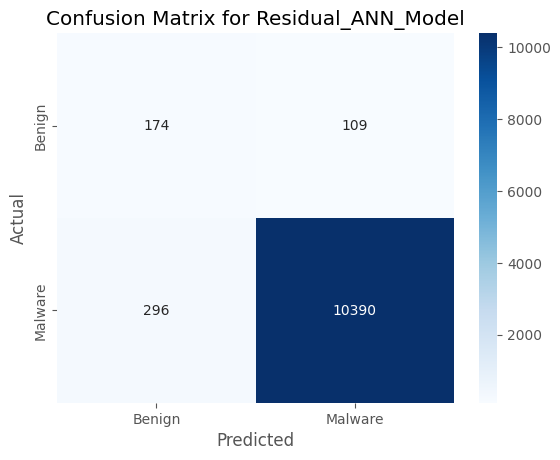

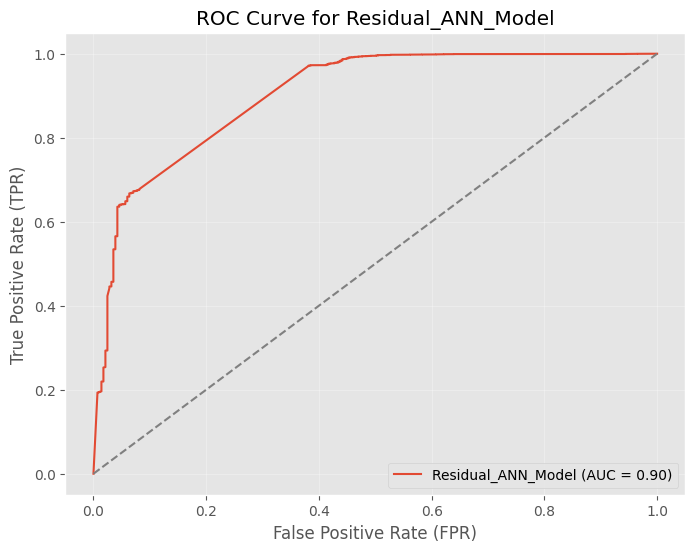

343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


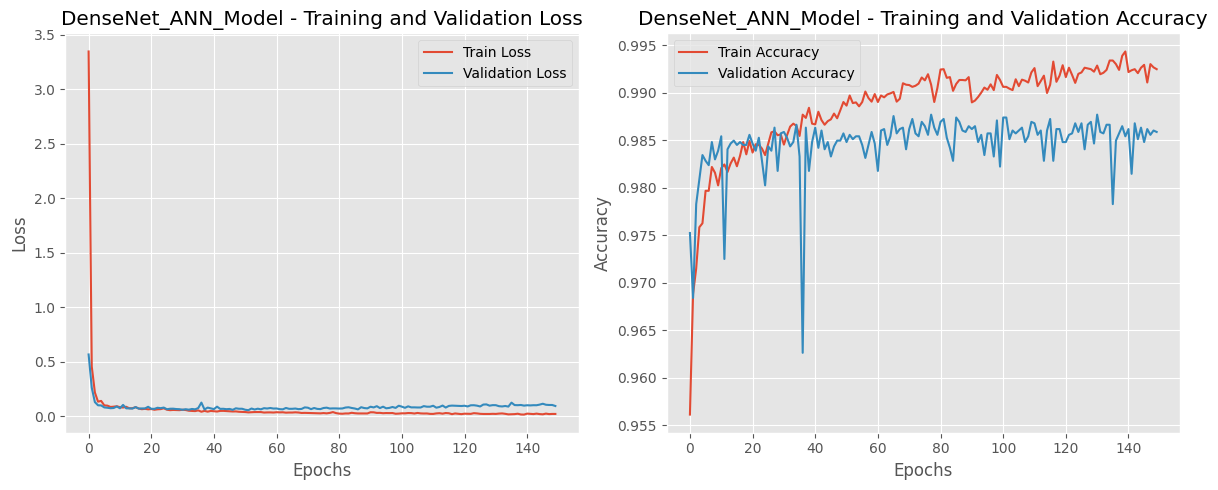


Classification Report for DenseNet_ANN_Model:
              precision    recall  f1-score   support

           0     0.7304    0.5265    0.6119       283
           1     0.9876    0.9949    0.9912     10686

    accuracy                         0.9828     10969
   macro avg     0.8590    0.7607    0.8015     10969
weighted avg     0.9809    0.9828    0.9814     10969


Confusion Matrix for DenseNet_ANN_Model:
[[  149   134]
 [   55 10631]]


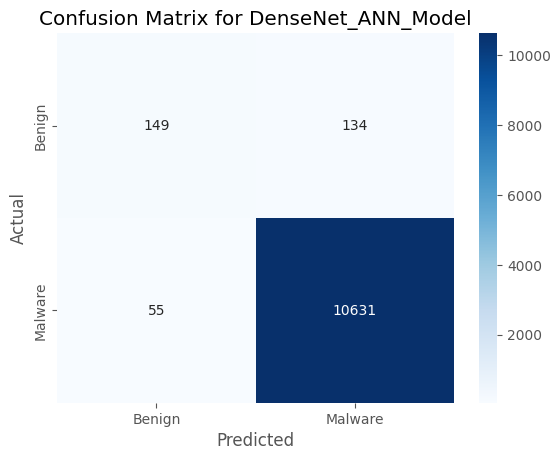

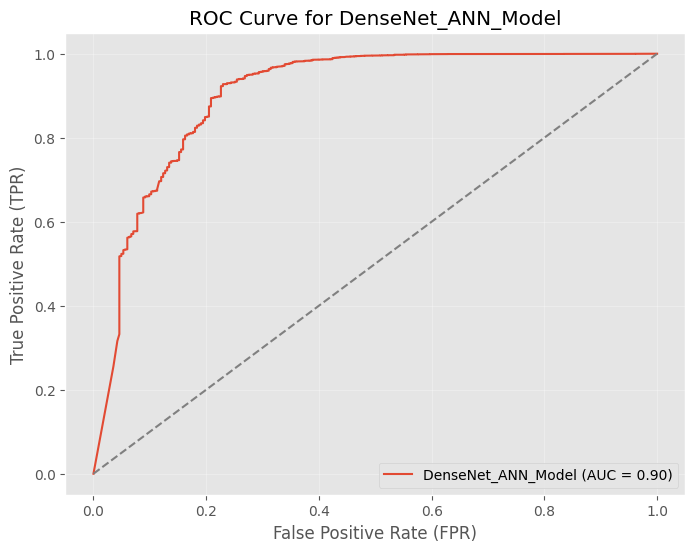

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


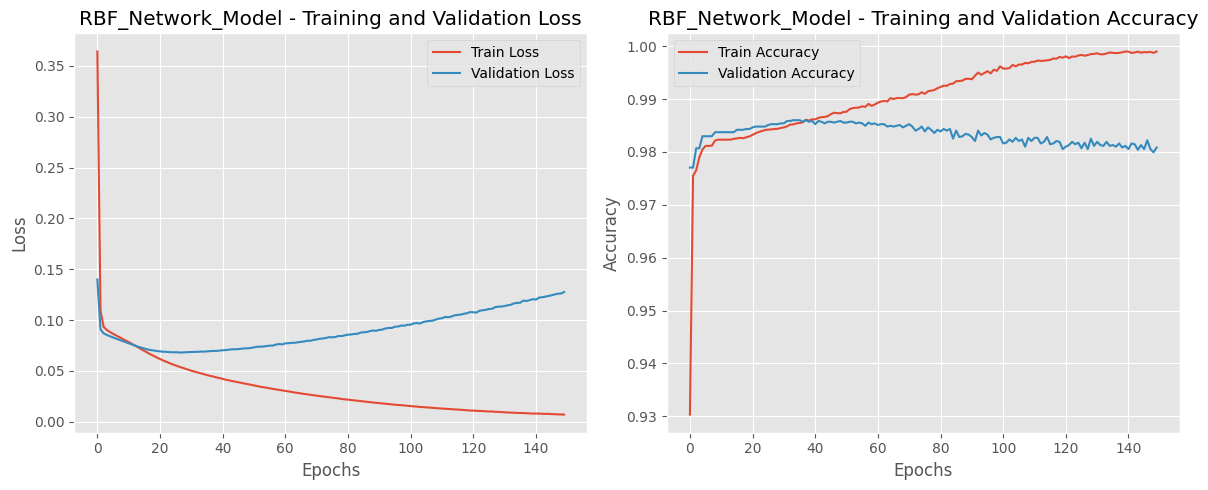


Classification Report for RBF_Network_Model:
              precision    recall  f1-score   support

           0     0.6701    0.4594    0.5451       283
           1     0.9858    0.9940    0.9899     10686

    accuracy                         0.9802     10969
   macro avg     0.8280    0.7267    0.7675     10969
weighted avg     0.9777    0.9802    0.9784     10969


Confusion Matrix for RBF_Network_Model:
[[  130   153]
 [   64 10622]]


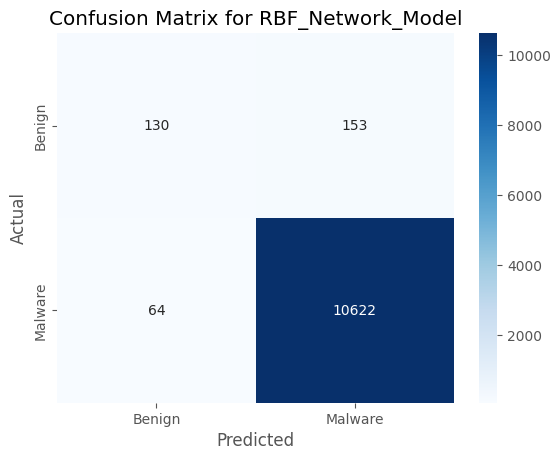

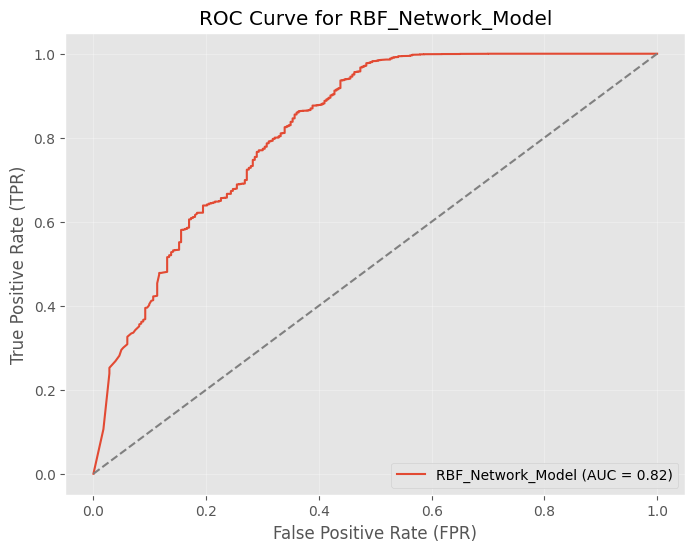

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
343/343 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


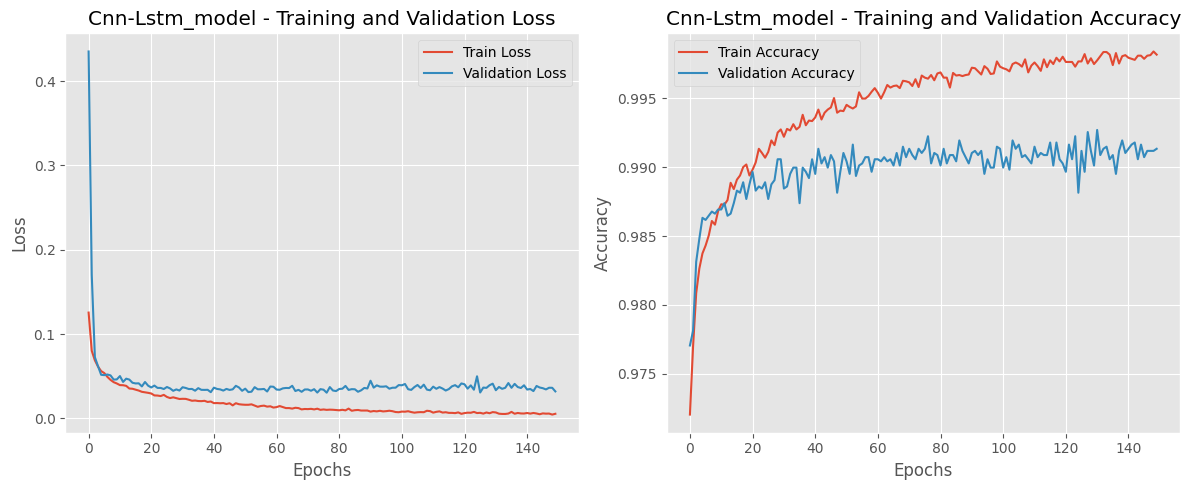


Classification Report for Cnn-Lstm_model:
              precision    recall  f1-score   support

           0     0.8884    0.7032    0.7850       283
           1     0.9922    0.9977    0.9949     10686

    accuracy                         0.9901     10969
   macro avg     0.9403    0.8504    0.8900     10969
weighted avg     0.9895    0.9901    0.9895     10969


Confusion Matrix for Cnn-Lstm_model:
[[  199    84]
 [   25 10661]]


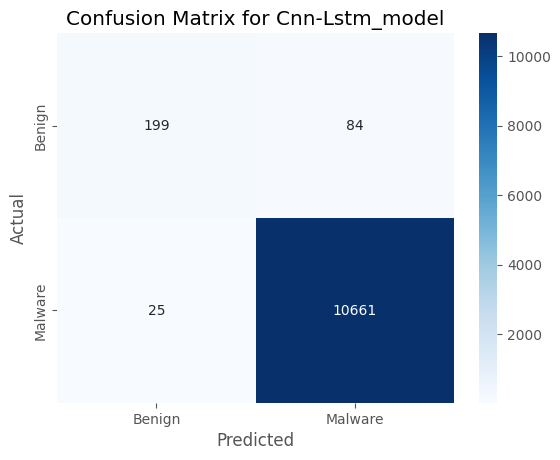

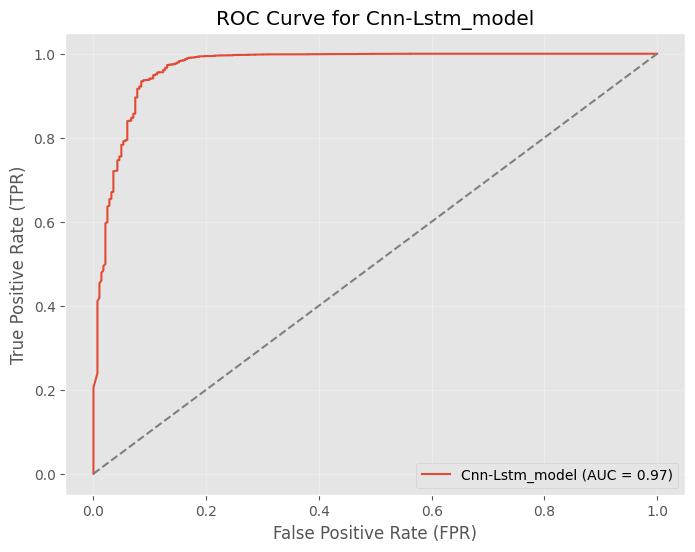

                            Model  Accuracy  F1-Score    Recall  Precision  \
6                  Cnn-Lstm_model  0.990063  0.994914  0.997660   0.992182   
0                Simple_ANN_Model  0.984046  0.991847  0.996163   0.987568   
1                       MLP_Model  0.983408  0.991520  0.995695   0.987379   
2  Enhanced_DropConnect_ANN_Model  0.983043  0.991363  0.998971   0.983871   
4              DenseNet_ANN_Model  0.982770  0.991189  0.994853   0.987552   
5               RBF_Network_Model  0.980217  0.989889  0.994011   0.985800   
3              Residual_ANN_Model  0.963078  0.980883  0.972300   0.989618   

   False Positives (FP)  False Negatives (FN)   ROC-AUC  
6                    84                    25  0.968776  
0                   134                    41  0.932958  
1                   136                    46  0.925334  
2                   175                    11  0.927979  
4                   134                    55  0.904389  
5                   153    

In [76]:
unique_api_calls = 307
epoch = 150

# List of models to train
results = []
results.append(train_simple_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_mlp(X_train, y_train, X_test, y_test, epoch))
results.append(train_dropconnect_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_residual_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_densenet_ann(X_train, y_train, X_test, y_test, epoch))
results.append(train_rbf_network(X_train, y_train, X_test, y_test, epoch))
results.append(train_cnn_lstm(X_train, y_train, X_test, y_test, unique_api_calls, epoch)) 

# Display results in a sorted DataFrame
df_results = pd.DataFrame(results)
df_results = df_results.sort_values(by=["Accuracy", "ROC-AUC", "False Positives (FP)", "False Negatives (FN)"], ascending=[False, True, True,True])
print(df_results)


In [ ]:
# Combine the results for comparison
df_results_50['Epochs'] = '50'
df_results_150['Epochs'] = '150'

# Combine the results into a single DataFrame for visualization
df_combined = pd.concat([df_results_50, df_results_150], axis=0)

# Add a unique identifier for each model
df_combined['Model_Epochs'] = df_combined['Model'] + " (Epochs: " + df_combined['Epochs'] + ")"

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy Comparison Bar Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=df_combined, x='Model', y='Accuracy', hue='Epochs', palette='Blues')

# Add numbers on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=10, padding=5)

# Titles and labels
plt.title("Model Accuracy Comparison (Epochs: 50 vs. 150)", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks(rotation=45, ha='right')

# Move legend directly below the "CNN-LSTM" label
plt.legend(
    title="Epochs",
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.02, -0.25),  # Adjust x=0.1 to align under "CNN-LSTM"
    ncol=1  # Single column for compact legend
)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ROC-AUC Comparison Bar Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=df_combined, x='Model', y='ROC-AUC', hue='Epochs', palette='Greens')

# Add numbers on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=10, padding=5)

# Titles and labels
plt.title("Model ROC-AUC Comparison (Epochs: 50 vs. 150)", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("ROC-AUC", fontsize=14)
plt.xticks(rotation=45, ha='right')

# Move legend directly below the "CNN-LSTM" label
plt.legend(
    title="Epochs",
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.02, -0.25),  # Adjust x=0.02 to align under "CNN-LSTM"
    ncol=1  # Single column for compact legend
)

plt.tight_layout()
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# False Negatives (FN) Comparison Bar Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=df_combined, x='Model', y='False Negatives (FN)', hue='Epochs', palette='Reds')

# Add numbers on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', fontsize=10, padding=5)

# Titles and labels
plt.title("Model False Negatives (FN) Comparison (Epochs: 50 vs. 150)", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("False Negatives (FN)", fontsize=14)
plt.xticks(rotation=45, ha='right')

# Move legend directly below the "CNN-LSTM" label
plt.legend(
    title="Epochs",
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.02, -0.25),  # Adjust x=0.02 to align under "CNN-LSTM"
    ncol=1  # Single column for compact legend
)

plt.tight_layout()
plt.show()

In [ ]:
# False Positives (FP) Comparison Bar Plot
plt.figure(figsize=(14, 7))
sns.barplot(data=df_combined, x='Model', y='False Positives (FP)', hue='Epochs', palette='Purples')

# Add numbers on top of the bars
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%d', fontsize=10, padding=5)

# Titles and labels
plt.title("Model False Positives (FP) Comparison (Epochs: 50 vs. 150)", fontsize=16)
plt.xlabel("Model", fontsize=14)
plt.ylabel("False Positives (FP)", fontsize=14)
plt.xticks(rotation=45, ha='right')

# Move legend directly below the "CNN-LSTM" label
plt.legend(
    title="Epochs",
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.02, -0.25),  # Adjust x=0.02 to align under "CNN-LSTM"
    ncol=1  # Single column for compact legend
)

plt.tight_layout()
plt.show()